In [1]:
!pip install xgboost
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_score
from xgboost import XGBClassifier
import streamlit as st

Defaulting to user installation because normal site-packages is not writeable


In [2]:
df=pd.read_csv("BP control dataset.csv")
print(df)

    Patient_ID  Age  Gender Diabetes_Mellitus Chronic_Kidney_Disease  \
0      HTN0001   70    Male               Yes                     No   
1      HTN0002   35    Male               Yes                    Yes   
2      HTN0003   39    Male                No                    Yes   
3      HTN0004   54    Male                No                     No   
4      HTN0005   59  Female               Yes                     No   
..         ...  ...     ...               ...                    ...   
345    HTN0346   55    Male               Yes                    Yes   
346    HTN0347   74  Female                No                    Yes   
347    HTN0348   46    Male                No                     No   
348    HTN0349   58    Male               Yes                    Yes   
349    HTN0350   41  Female                No                    Yes   

    Dyslipidemia Obesity  Baseline_Systolic_BP  Baseline_Diastolic_BP  \
0            Yes     Yes                   148                

In [3]:
BPd= df.copy()

In [4]:
BPd["Gender"] = BPd["Gender"].map({"Female": 0, "Male": 1})

In [5]:
yes_no_cols = [
    "Diabetes_Mellitus",
    "Chronic_Kidney_Disease",
    "Dyslipidemia",
    "Obesity",
    "BP_Controlled_After_3_Months"
]

for col in yes_no_cols:
    BPd[col] = BPd[col].map({"Yes": 1, "No": 0})

In [6]:
BPd.head()

,Patient_ID,Age,Gender,Diabetes_Mellitus,Chronic_Kidney_Disease,Dyslipidemia,Obesity,Baseline_Systolic_BP,Baseline_Diastolic_BP,Antihypertensive_Class,Medication_Adherence,Followup_Systolic_BP,Followup_Diastolic_BP,BP_Controlled_After_3_Months,Number_of_Visits,Registration_Date
0,HTN0001,70,1,1,0,1,1,148,113,ACE Inhibitor,Poor,142,110,0,1,1/16/2024
1,HTN0002,35,1,1,1,1,0,154,104,Beta Blocker,Moderate,144,98,0,3,5/22/2024
2,HTN0003,39,1,0,1,1,0,146,101,Calcium Channel Blocker,Poor,139,97,0,5,3/4/2024
3,HTN0004,54,1,0,0,1,1,142,111,ARB,Moderate,131,105,0,4,5/22/2024
4,HTN0005,59,0,1,0,0,1,182,98,Combination Therapy,Poor,166,89,0,5,5/5/2024


In [7]:
control_rate = BPd["BP_Controlled_After_3_Months"].mean() * 100
print(f"Percentage controlled: {control_rate:.2f}%")

Percentage controlled: 9.43%


In [8]:
adherence_control = (
    BPd.groupby("Medication_Adherence")["BP_Controlled_After_3_Months"]
    .mean() * 100
)
adherence_control= adherence_control.round(2)
print(adherence_control)

Medication_Adherence
Good        15.24
Moderate    11.36
Poor         1.77
Name: BP_Controlled_After_3_Months, dtype: float64


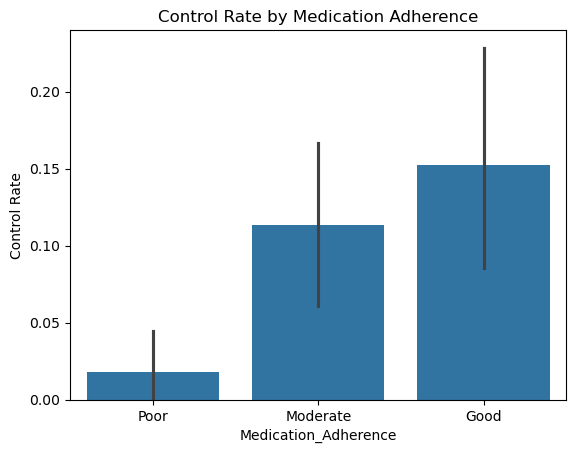

In [9]:
sns.barplot(
    x="Medication_Adherence",
    y="BP_Controlled_After_3_Months",
    data=BPd
)
plt.title("Control Rate by Medication Adherence")
plt.ylabel("Control Rate")
plt.show()

In [10]:

drug_control = BPd.groupby("Antihypertensive_Class")["BP_Controlled_After_3_Months"].mean() * 100
drug_control = drug_control.sort_values(ascending=False)
drug_control = drug_control.round(2)
print(drug_control)

Antihypertensive_Class
Combination Therapy        21.05
Thiazide Diuretic          13.11
Beta Blocker                9.84
ARB                         5.88
Calcium Channel Blocker     5.17
ACE Inhibitor               0.00
Name: BP_Controlled_After_3_Months, dtype: float64


In [11]:
BPd["Antihypertensive_Class"].value_counts()

Antihypertensive_Class
ARB                        68
Beta Blocker               61
Thiazide Diuretic          61
Calcium Channel Blocker    58
Combination Therapy        57
ACE Inhibitor              45
Name: count, dtype: int64

In [12]:
ace_patients = BPd[BPd["Antihypertensive_Class"] == "ACE Inhibitor"]
ace_patients

,Patient_ID,Age,Gender,Diabetes_Mellitus,Chronic_Kidney_Disease,Dyslipidemia,Obesity,Baseline_Systolic_BP,Baseline_Diastolic_BP,Antihypertensive_Class,Medication_Adherence,Followup_Systolic_BP,Followup_Diastolic_BP,BP_Controlled_After_3_Months,Number_of_Visits,Registration_Date
0,HTN0001,70,1,1,0,1,1,148,113,ACE Inhibitor,Poor,142,110,0,1,1/16/2024
5,HTN0006,40,0,0,0,1,0,189,114,ACE Inhibitor,Good,173,105,0,3,2/3/2024
10,HTN0011,37,0,0,1,1,1,176,120,ACE Inhibitor,Good,146,102,0,2,3/6/2024
16,HTN0017,59,1,1,0,1,1,181,107,ACE Inhibitor,Good,159,94,0,4,9/3/2024
18,HTN0019,39,1,0,1,1,1,187,100,ACE Inhibitor,Good,157,82,0,2,1/30/2024
21,HTN0022,59,1,1,1,0,1,162,118,ACE Inhibitor,Good,136,103,0,4,10/5/2024
22,HTN0023,75,0,1,0,1,1,156,93,ACE Inhibitor,Poor,152,91,0,5,4/17/2024
42,HTN0043,47,0,0,1,0,1,187,107,ACE Inhibitor,Moderate,169,97,0,6,1/21/2024
44,HTN0045,46,0,1,1,1,0,146,108,ACE Inhibitor,Moderate,132,100,0,1,10/30/2024
87,HTN0088,62,1,0,1,1,0,169,110,ACE Inhibitor,Good,139,92,0,6,2/25/2024


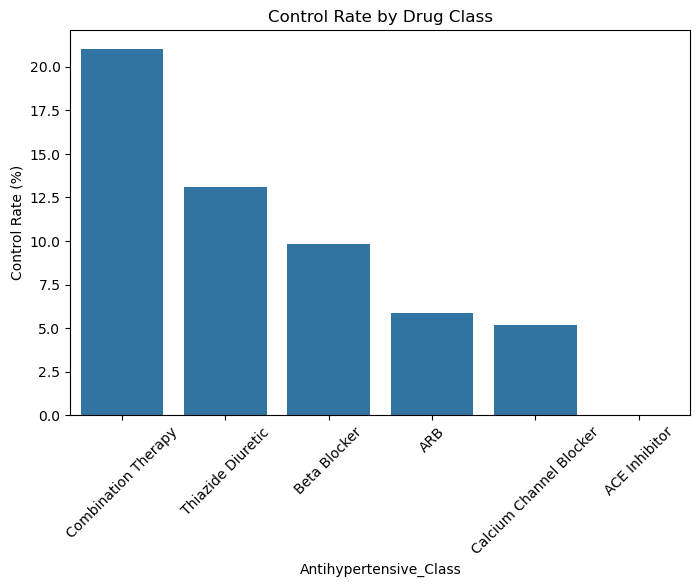

In [13]:
plt.figure(figsize=(8,5))
sns.barplot(
    x=drug_control.index,
    y=drug_control.values
)
plt.xticks(rotation=45)
plt.ylabel("Control Rate (%)")
plt.title("Control Rate by Drug Class")
plt.show()

In [14]:
CKD_control = (
    BPd.groupby("Chronic_Kidney_Disease")["BP_Controlled_After_3_Months"]
    .mean() * 100
)
CKD_control= CKD_control.round(2)
CKD_control

Chronic_Kidney_Disease
0    11.90
1     7.14
Name: BP_Controlled_After_3_Months, dtype: float64

In [15]:
Dyslipidemia_control = (
    BPd.groupby("Dyslipidemia")["BP_Controlled_After_3_Months"]
    .mean() * 100
)
Dyslipidemia_control= Dyslipidemia_control.round(2)
Dyslipidemia_control

Dyslipidemia
0     8.56
1    10.43
Name: BP_Controlled_After_3_Months, dtype: float64

In [16]:
Obesity_control = (
    BPd.groupby("Obesity")["BP_Controlled_After_3_Months"]
    .mean() * 100
)
Obesity_control= Obesity_control.round(2)
Obesity_control

Obesity
0    9.76
1    9.14
Name: BP_Controlled_After_3_Months, dtype: float64

In [17]:
result= pd.crosstab(BPd["Medication_Adherence"], BPd["Antihypertensive_Class"], values=BPd["BP_Controlled_After_3_Months"], aggfunc="mean") * 100
result



Antihypertensive_Class,ACE Inhibitor,ARB,Beta Blocker,Calcium Channel Blocker,Combination Therapy,Thiazide Diuretic
Medication_Adherence,,,,,,
Good,0.0,23.076923,15.789474,5.882353,25.00,25.0
Moderate,0.0,3.703704,14.285714,4.545455,28.00,12.5
Poor,0.0,0.000000,0.000000,5.263158,6.25,0.0


In [18]:
pd.crosstab(
    [BPd["Medication_Adherence"]],
    BPd["Antihypertensive_Class"],
    margins=True
)

Antihypertensive_Class,ACE Inhibitor,ARB,Beta Blocker,Calcium Channel Blocker,Combination Therapy,Thiazide Diuretic,All
Medication_Adherence,,,,,,,
Good,20,13,19,17,16,20,105
Moderate,13,27,21,22,25,24,132
Poor,12,28,21,19,16,17,113
All,45,68,61,58,57,61,350


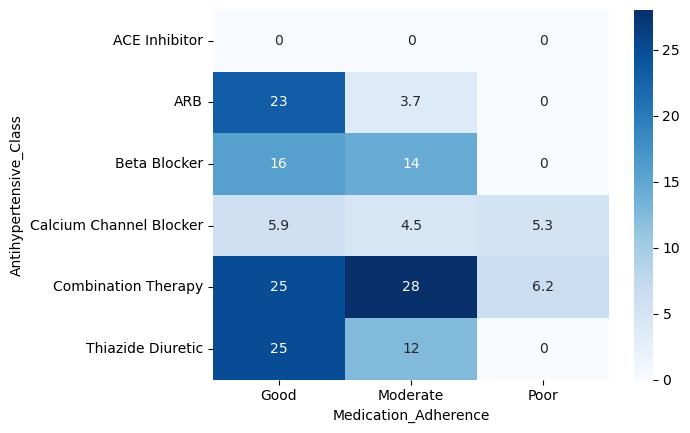

In [19]:
sns.heatmap(result.T, annot=True, cmap="Blues")
plt.show()

In [20]:


Drugs works well on each patient

SyntaxError: invalid syntax (2535201774.py, line 1)

In [21]:
CKD_patient= pd.crosstab(BPd["Chronic_Kidney_Disease"], BPd["Antihypertensive_Class"], values=BPd["BP_Controlled_After_3_Months"], aggfunc="mean") * 100
CKD_patient

Antihypertensive_Class,ACE Inhibitor,ARB,Beta Blocker,Calcium Channel Blocker,Combination Therapy,Thiazide Diuretic
Chronic_Kidney_Disease,,,,,,
0,0.0,8.108108,15.384615,6.896552,29.032258,7.407407
1,0.0,3.225806,5.714286,3.448276,11.538462,17.647059


In [22]:
Obesity_patient=  pd.crosstab(BPd["Obesity"], BPd["Antihypertensive_Class"], values=BPd["BP_Controlled_After_3_Months"], aggfunc="mean") * 100
Obesity_patient

Antihypertensive_Class,ACE Inhibitor,ARB,Beta Blocker,Calcium Channel Blocker,Combination Therapy,Thiazide Diuretic
Obesity,,,,,,
0,0.0,3.030303,14.705882,3.225806,26.315789,15.384615
1,0.0,8.571429,3.703704,7.407407,18.421053,11.428571


In [23]:
Diabetes_patient= pd.crosstab(BPd["Diabetes_Mellitus"], BPd["Antihypertensive_Class"], values=BPd["BP_Controlled_After_3_Months"], aggfunc="mean") * 100
Diabetes_patient

Antihypertensive_Class,ACE Inhibitor,ARB,Beta Blocker,Calcium Channel Blocker,Combination Therapy,Thiazide Diuretic
Diabetes_Mellitus,,,,,,
0,0.0,5.555556,12.500000,6.250000,16.0,16.000000
1,0.0,6.250000,8.108108,3.846154,25.0,11.111111


In [24]:
Dyslipidemia= pd.crosstab(BPd["Dyslipidemia"], BPd["Antihypertensive_Class"], values=BPd["BP_Controlled_After_3_Months"], aggfunc="mean") * 100
Dyslipidemia

Antihypertensive_Class,ACE Inhibitor,ARB,Beta Blocker,Calcium Channel Blocker,Combination Therapy,Thiazide Diuretic
Dyslipidemia,,,,,,
0,0.0,5.405405,9.375000,7.407407,16.666667,10.810811
1,0.0,6.451613,10.344828,3.225806,25.925926,16.666667


In [25]:
#  Baseline BP severity

BPd["Baseline_BP_Category"] = pd.cut(
    BPd["Baseline_Systolic_BP"],
    bins=[0, 120, 130, 140, 180, float("inf")],
    labels=["Normal", "Elevated", "Mild", "Moderate", "Severe"]
)

result = BPd.groupby("Baseline_BP_Category")["BP_Controlled_After_3_Months"].mean() * 100

result.round(2)

C:\Users\Elim Gideon Moses\AppData\Local\Temp\ipykernel_10576\1808195676.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result = BPd.groupby("Baseline_BP_Category")["BP_Controlled_After_3_Months"].mean() * 100


Baseline_BP_Category
Normal        NaN
Elevated      NaN
Mild        50.00
Moderate    11.11
Severe       0.00
Name: BP_Controlled_After_3_Months, dtype: float64

In [26]:
#Effect of Follow-Up Visits

Result= BPd.groupby("Number_of_Visits")["BP_Controlled_After_3_Months"].mean() * 100
Result.round(2)

Number_of_Visits
1     5.26
2    15.94
3     4.41
4     7.14
5     9.30
6    14.04
Name: BP_Controlled_After_3_Months, dtype: float64

In [27]:
BPd["Number_of_Visits"].value_counts()

Number_of_Visits
2    69
3    68
1    57
6    57
4    56
5    43
Name: count, dtype: int64

In [28]:
#Age Effects 

BPd["Age_Group"] = pd.cut(
    BPd["Age"],
    bins=[0, 40, 55, 70, 100],
    labels=["Young", "Middle", "Older", "Elderly"]
)
Result2 = BPd.groupby("Age_Group")["BP_Controlled_After_3_Months"].mean() * 100
Result2.round(2)

C:\Users\Elim Gideon Moses\AppData\Local\Temp\ipykernel_10576\3385112859.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  Result2 = BPd.groupby("Age_Group")["BP_Controlled_After_3_Months"].mean() * 100


Age_Group
Young       7.46
Middle     12.12
Older      10.34
Elderly     7.22
Name: BP_Controlled_After_3_Months, dtype: float64

In [29]:
#Multi Risk burden Score

BPd["Risk_Score"] = (
    BPd["Diabetes_Mellitus"] +
    BPd["Chronic_Kidney_Disease"] +
    BPd["Dyslipidemia"] +
    BPd["Obesity"]
)
Result3= BPd.groupby("Risk_Score")["BP_Controlled_After_3_Months"].agg(["mean", "count"])
Result3["mean"] = Result3["mean"] * 100
Result3.round(2)

,mean,count
Risk_Score,,
0,17.65,17
1,8.79,91
2,8.87,124
3,9.18,98
4,10.00,20


In [30]:
#Baseline BP vs follow-up improvement. To create Improvement

BPd["SBP_Change"] = BPd["Baseline_Systolic_BP"] - BPd["Followup_Systolic_BP"]
Result4= BPd.groupby("BP_Controlled_After_3_Months")["SBP_Change"].mean()
Result4.round(2)

BP_Controlled_After_3_Months
0    13.68
1    22.27
Name: SBP_Change, dtype: float64

In [31]:
#Medication effectiveness within severity groups

Result5= pd.crosstab(
    BPd["Antihypertensive_Class"],
    BPd["Baseline_BP_Category"],
    values=BPd["BP_Controlled_After_3_Months"],
    aggfunc="mean"
) * 100
Result5.round(2)

Baseline_BP_Category,Mild,Moderate,Severe
Antihypertensive_Class,,,
ACE Inhibitor,NaN,0.00,0.0
ARB,33.33,5.66,0.0
Beta Blocker,100.00,11.36,0.0
Calcium Channel Blocker,0.00,8.11,0.0
Combination Therapy,100.00,22.92,0.0
Thiazide Diuretic,NaN,15.38,0.0


In [32]:
#Target Definition
y = BPd["BP_Controlled_After_3_Months"]

#Features Definition
X = BPd.drop(columns=[
    "BP_Controlled_After_3_Months",
    "Followup_Systolic_BP",
    "Followup_Diastolic_BP",
    "SBP_Change",
    "Risk_Score", 
    "Patient_ID",
    "Registration_Date"
])

#Encode Categorical Variables
X = pd.get_dummies(X, drop_first=True)

In [33]:
#Encode Categorical Variables
X = pd.get_dummies(X, drop_first=True)
X

,Age,Gender,Diabetes_Mellitus,Chronic_Kidney_Disease,Dyslipidemia,Obesity,Baseline_Systolic_BP,Baseline_Diastolic_BP,Number_of_Visits,Antihypertensive_Class_ARB,...,Antihypertensive_Class_Thiazide Diuretic,Medication_Adherence_Moderate,Medication_Adherence_Poor,Baseline_BP_Category_Elevated,Baseline_BP_Category_Mild,Baseline_BP_Category_Moderate,Baseline_BP_Category_Severe,Age_Group_Middle,Age_Group_Older,Age_Group_Elderly
0,70,1,1,0,1,1,148,113,1,False,...,False,False,True,False,False,True,False,False,True,False
1,35,1,1,1,1,0,154,104,3,False,...,False,True,False,False,False,True,False,False,False,False
2,39,1,0,1,1,0,146,101,5,False,...,False,False,True,False,False,True,False,False,False,False
3,54,1,0,0,1,1,142,111,4,True,...,False,True,False,False,False,True,False,True,False,False
4,59,0,1,0,0,1,182,98,5,False,...,False,False,True,False,False,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
345,55,1,1,1,0,0,174,91,4,False,...,False,True,False,False,False,True,False,True,False,False
346,74,0,0,1,1,1,164,108,2,False,...,False,True,False,False,False,True,False,False,False,True
347,46,1,0,0,0,0,151,105,4,False,...,True,False,False,False,False,True,False,True,False,False
348,58,1,1,1,1,0,155,107,4,False,...,True,True,False,False,False,True,False,False,True,False


In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print("Accuracy:", accuracy)
print("AUC:", auc)

Accuracy: 0.9428571428571428
AUC: 0.9663157894736841


In [35]:
xgb = XGBClassifier(
    eval_metric="logloss",
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:,1]

print("XGB Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("XGB AUC:", roc_auc_score(y_test, y_prob_xgb))

XGB Accuracy: 0.9714285714285714
XGB AUC: 0.9852631578947368


In [36]:
X.columns

Index(['Age', 'Gender', 'Diabetes_Mellitus', 'Chronic_Kidney_Disease',
       'Dyslipidemia', 'Obesity', 'Baseline_Systolic_BP',
       'Baseline_Diastolic_BP', 'Number_of_Visits',
       'Antihypertensive_Class_ARB', 'Antihypertensive_Class_Beta Blocker',
       'Antihypertensive_Class_Calcium Channel Blocker',
       'Antihypertensive_Class_Combination Therapy',
       'Antihypertensive_Class_Thiazide Diuretic',
       'Medication_Adherence_Moderate', 'Medication_Adherence_Poor',
       'Baseline_BP_Category_Elevated', 'Baseline_BP_Category_Mild',
       'Baseline_BP_Category_Moderate', 'Baseline_BP_Category_Severe',
       'Age_Group_Middle', 'Age_Group_Older', 'Age_Group_Elderly'],
      dtype='object')

In [37]:
print(X.columns)

Index(['Age', 'Gender', 'Diabetes_Mellitus', 'Chronic_Kidney_Disease',
       'Dyslipidemia', 'Obesity', 'Baseline_Systolic_BP',
       'Baseline_Diastolic_BP', 'Number_of_Visits',
       'Antihypertensive_Class_ARB', 'Antihypertensive_Class_Beta Blocker',
       'Antihypertensive_Class_Calcium Channel Blocker',
       'Antihypertensive_Class_Combination Therapy',
       'Antihypertensive_Class_Thiazide Diuretic',
       'Medication_Adherence_Moderate', 'Medication_Adherence_Poor',
       'Baseline_BP_Category_Elevated', 'Baseline_BP_Category_Mild',
       'Baseline_BP_Category_Moderate', 'Baseline_BP_Category_Severe',
       'Age_Group_Middle', 'Age_Group_Older', 'Age_Group_Elderly'],
      dtype='object')


In [38]:
pd.Series(model.coef_[0], index=X.columns)\
    .sort_values(key=abs, ascending=False).head(20)

Medication_Adherence_Poor                        -1.971201
Antihypertensive_Class_Combination Therapy        1.170222
Antihypertensive_Class_Thiazide Diuretic          0.975258
Medication_Adherence_Moderate                    -0.778511
Gender                                           -0.721570
Diabetes_Mellitus                                -0.622870
Chronic_Kidney_Disease                           -0.619535
Antihypertensive_Class_ARB                       -0.586057
Obesity                                           0.457389
Age_Group_Middle                                  0.383702
Baseline_Diastolic_BP                            -0.272081
Baseline_Systolic_BP                             -0.203133
Number_of_Visits                                 -0.161557
Age_Group_Elderly                                 0.094164
Age_Group_Older                                   0.072022
Baseline_BP_Category_Severe                      -0.062082
Baseline_BP_Category_Mild                         0.0504

In [39]:
print("Target in X?", "BP_Controlled_After_3_Months" in X.columns)

Target in X? False


In [40]:
corr = pd.concat([X, y], axis=1).corr()["BP_Controlled_After_3_Months"].sort_values(ascending=False)
print(corr.head(10))

BP_Controlled_After_3_Months                  1.000000
Baseline_BP_Category_Mild                     0.183357
Antihypertensive_Class_Combination Therapy    0.175446
Baseline_BP_Category_Moderate                 0.105775
Antihypertensive_Class_Thiazide Diuretic      0.057953
Age_Group_Middle                              0.057868
Medication_Adherence_Moderate                 0.051527
Number_of_Visits                              0.039205
Dyslipidemia                                  0.031977
Age_Group_Older                               0.018034
Name: BP_Controlled_After_3_Months, dtype: float64


In [41]:
xgb_model = XGBClassifier(max_depth=3, random_state=42)

scores = cross_val_score(xgb_model, X, y, cv=5, scoring="roc_auc")

print("CV AUC scores:", scores)
print("Mean CV AUC:", scores.mean())

CV AUC scores: [1.         0.98697917 0.95011338 0.98866213 0.94557823]
Mean CV AUC: 0.974266581632653


In [42]:
models = LogisticRegression(max_iter=1000)


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(
    models,
    X,
    y,
    cv=cv,
    scoring="roc_auc"
)

print("CV AUC scores:", scores.round(3))
print("Mean CV AUC:", scores.mean().round(3))
print("Std:", scores.std().round(3))

CV AUC scores: [0.93  0.99  0.982 0.932 0.977]
Mean CV AUC: 0.962
Std: 0.026


In [43]:
xgb = XGBClassifier(
    max_depth=3,
    learning_rate=0.1,
    n_estimators=100,
    eval_metric="logloss",
    random_state=42
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(
    xgb,
    X,
    y,
    cv=cv,
    scoring="roc_auc"
)

print("CV AUC scores:", scores.round(3))
print("Mean CV AUC:", scores.mean().round(3))
print("Std:", scores.std().round(3))

CV AUC scores: [0.948 0.987 0.995 0.937 0.971]
Mean CV AUC: 0.967
Std: 0.022


In [44]:
corr = pd.concat([X, y], axis=1).corr()["BP_Controlled_After_3_Months"]

print(corr.sort_values(ascending=False))

BP_Controlled_After_3_Months                      1.000000
Baseline_BP_Category_Mild                         0.183357
Antihypertensive_Class_Combination Therapy        0.175446
Baseline_BP_Category_Moderate                     0.105775
Antihypertensive_Class_Thiazide Diuretic          0.057953
Age_Group_Middle                                  0.057868
Medication_Adherence_Moderate                     0.051527
Number_of_Visits                                  0.039205
Dyslipidemia                                      0.031977
Age_Group_Older                                   0.018034
Diabetes_Mellitus                                 0.016439
Antihypertensive_Class_Beta Blocker               0.006406
Obesity                                          -0.010524
Age                                              -0.028268
Age_Group_Elderly                                -0.046871
Antihypertensive_Class_ARB                       -0.059590
Gender                                           -0.0629

In [45]:
feature_table = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

# Rank by strength of effect (absolute value)
feature_table["Abs_Coefficient"] = feature_table["Coefficient"].abs()

feature_table = feature_table.sort_values(
    by="Abs_Coefficient",
    ascending=False
)

feature_table.head(20)


,Feature,Coefficient,Abs_Coefficient
15,Medication_Adherence_Poor,-1.971201,1.971201
12,Antihypertensive_Class_Combination Therapy,1.170222,1.170222
13,Antihypertensive_Class_Thiazide Diuretic,0.975258,0.975258
14,Medication_Adherence_Moderate,-0.778511,0.778511
1,Gender,-0.721570,0.721570
2,Diabetes_Mellitus,-0.622870,0.622870
3,Chronic_Kidney_Disease,-0.619535,0.619535
9,Antihypertensive_Class_ARB,-0.586057,0.586057
5,Obesity,0.457389,0.457389
20,Age_Group_Middle,0.383702,0.383702


In [46]:
def direction(x):
    if x > 0:
        return "↑ higher chance of BP control (protective)"
    elif x < 0:
        return "↓ lower chance of BP control (risk factor)"
    else:
        return "no effect"

feature_table["Direction"] = feature_table["Coefficient"].apply(direction) 
feature_table

,Feature,Coefficient,Abs_Coefficient,Direction
15,Medication_Adherence_Poor,-1.971201,1.971201,↓ lower chance of BP control (risk factor)
12,Antihypertensive_Class_Combination Therapy,1.170222,1.170222,↑ higher chance of BP control (protective)
13,Antihypertensive_Class_Thiazide Diuretic,0.975258,0.975258,↑ higher chance of BP control (protective)
14,Medication_Adherence_Moderate,-0.778511,0.778511,↓ lower chance of BP control (risk factor)
1,Gender,-0.721570,0.721570,↓ lower chance of BP control (risk factor)
2,Diabetes_Mellitus,-0.622870,0.622870,↓ lower chance of BP control (risk factor)
3,Chronic_Kidney_Disease,-0.619535,0.619535,↓ lower chance of BP control (risk factor)
9,Antihypertensive_Class_ARB,-0.586057,0.586057,↓ lower chance of BP control (risk factor)
5,Obesity,0.457389,0.457389,↑ higher chance of BP control (protective)
20,Age_Group_Middle,0.383702,0.383702,↑ higher chance of BP control (protective)


In [47]:
def clinical_description(feature):

    if "Medication_Adherence_Poor" in feature:
        return "Severely reduced medication adherence"

    if "Medication_Adherence_Moderate" in feature:
        return "Partially reduced medication adherence"

    if "Combination Therapy" in feature:
        return "Best therapy for hypertension"

    if "Thiazide" in feature:
        return "Most effective antihypertensive drug"

    if "ARB" in feature:
        return "Highly effective antihypertensive drug"

    if "Beta Blocker" in feature:
        return "Moderately effective antihypertensive drug"

    if "Calcium Channel Blocker" in feature:
        return "Minimally effective antihypertensive drug"

    if any(x in feature for x in ["Diabetes", "Chronic_Kidney", "Dyslipidemia", "Obesity"]):
        return "Comorbidity risk burden"

    if "Baseline_Systolic" in feature or "Baseline_Diastolic" in feature:
        return "Baseline BP severity"

    if "Baseline_BP_Category" in feature:
        return "Hypertension severity classification level"

    if "Number_of_Visits" in feature:
        return "Healthcare follow-up intensity level"

    if "Age_Group" in feature or "Age" in feature:
        return "Age-related vascular risk factor"

    if "Gender" in feature:
        return "Biological sex treatment variation"

    return "Clinical BP outcome predictor"


feature_table["Clinical_Description"] = feature_table["Feature"].apply(clinical_description)

final_table = feature_table.sort_values(
    "Abs_Coefficient",
    ascending=False
)[["Feature", "Coefficient", "Direction", "Clinical_Description"]]

final_table

,Feature,Coefficient,Direction,Clinical_Description
15,Medication_Adherence_Poor,-1.971201,↓ lower chance of BP control (risk factor),Severely reduced medication adherence
12,Antihypertensive_Class_Combination Therapy,1.170222,↑ higher chance of BP control (protective),Best therapy for hypertension
13,Antihypertensive_Class_Thiazide Diuretic,0.975258,↑ higher chance of BP control (protective),Most effective antihypertensive drug
14,Medication_Adherence_Moderate,-0.778511,↓ lower chance of BP control (risk factor),Partially reduced medication adherence
1,Gender,-0.721570,↓ lower chance of BP control (risk factor),Biological sex treatment variation
2,Diabetes_Mellitus,-0.622870,↓ lower chance of BP control (risk factor),Comorbidity risk burden
3,Chronic_Kidney_Disease,-0.619535,↓ lower chance of BP control (risk factor),Comorbidity risk burden
9,Antihypertensive_Class_ARB,-0.586057,↓ lower chance of BP control (risk factor),Highly effective antihypertensive drug
5,Obesity,0.457389,↑ higher chance of BP control (protective),Comorbidity risk burden
20,Age_Group_Middle,0.383702,↑ higher chance of BP control (protective),Age-related vascular risk factor


In [48]:
#VISUALIZATION 

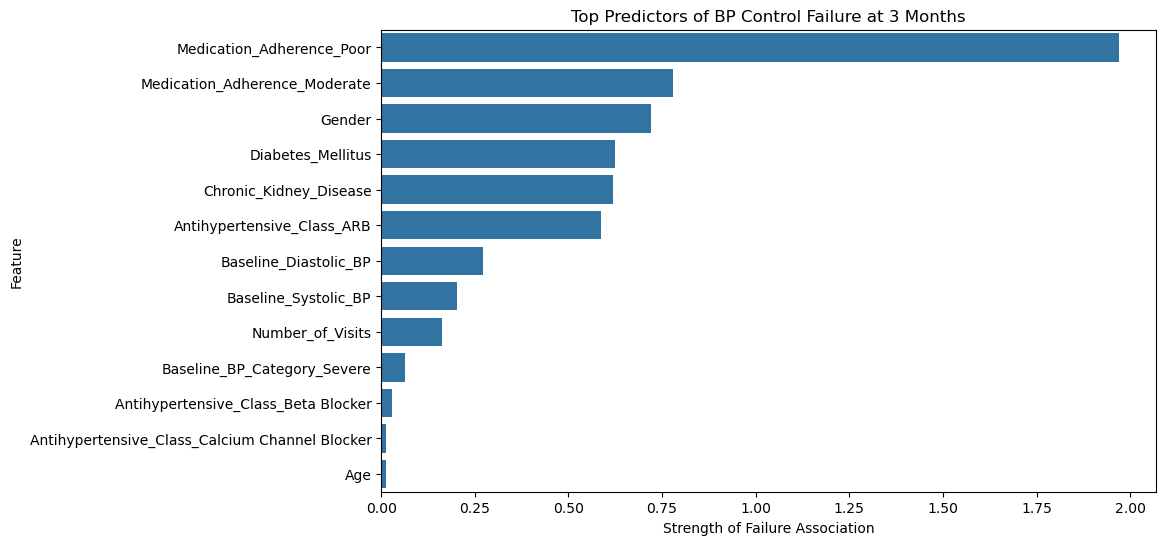

In [49]:
#Top Predictors of BP Failure After 3 Months

risk_features = feature_table[feature_table["Coefficient"] < 0] \
    .sort_values("Abs_Coefficient", ascending=False) \
    .head(15)

plt.figure(figsize=(10,6))

sns.barplot(
    data=risk_features,
    x="Abs_Coefficient",
    y="Feature"
)

plt.title("Top Predictors of BP Control Failure at 3 Months")
plt.xlabel("Strength of Failure Association")
plt.ylabel("Feature")

plt.show()

In [71]:
print(risk_features)

                                           Feature  Coefficient  \
15                       Medication_Adherence_Poor    -1.971201   
14                   Medication_Adherence_Moderate    -0.778511   
1                                           Gender    -0.721570   
2                                Diabetes_Mellitus    -0.622870   
3                           Chronic_Kidney_Disease    -0.619535   
9                       Antihypertensive_Class_ARB    -0.586057   
7                            Baseline_Diastolic_BP    -0.272081   
6                             Baseline_Systolic_BP    -0.203133   
8                                 Number_of_Visits    -0.161557   
19                     Baseline_BP_Category_Severe    -0.062082   
10             Antihypertensive_Class_Beta Blocker    -0.028685   
11  Antihypertensive_Class_Calcium Channel Blocker    -0.012306   
0                                              Age    -0.011283   

    Abs_Coefficient                                   Directi

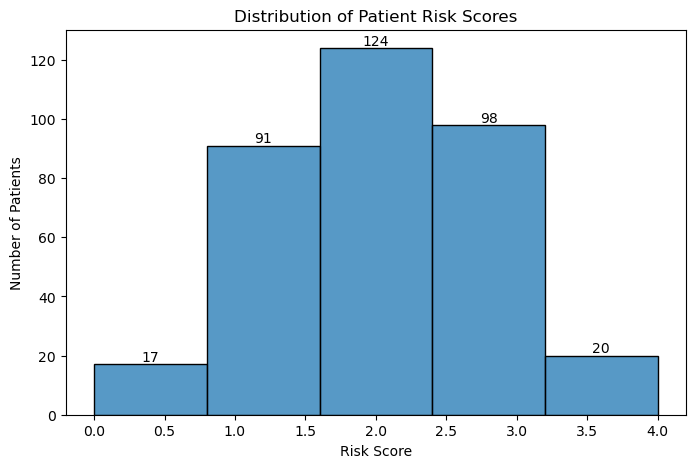

In [50]:
#RISK SCORE DISTRIBUTION

plt.figure(figsize=(8,5))

ax = sns.histplot(BPd["Risk_Score"], bins=5)

# Add counts on top of bars
for p in ax.patches:
    ax.annotate(
        int(p.get_height()),
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center',
        va='bottom'
    )

plt.title("Distribution of Patient Risk Scores")
plt.xlabel("Risk Score")
plt.ylabel("Number of Patients")

plt.show()

In [55]:
#PREDICTING THE RISK SCORE OF A PATIENT

def predict_risk(
    diabetes,
    ckd,
    dyslipidemia,
    obesity,
    systolic_bp,
    adherence
):
    
    risk_score = 0
    
    # Comorbidities
    risk_score += 2 * diabetes
    risk_score += 2 * ckd
    risk_score += 1 * dyslipidemia
    risk_score += 1 * obesity
    
    # BP severity
    if systolic_bp >= 160:
        risk_score += 2
    elif systolic_bp >= 140:
        risk_score += 1
    
    # Adherence
    if adherence == "Poor":
        risk_score += 2
    elif adherence == "Moderate":
        risk_score += 1
    
    # Risk classification (FIXED INDENTATION)
    if risk_score <= 2:
        return "Low Risk", risk_score
    elif risk_score <= 5:
        return "Moderate Risk", risk_score
    else:
        return "High Risk", risk_score

predict_risk(
    diabetes=1,
    ckd=1,
    dyslipidemia=0,
    obesity=1,
    systolic_bp=170,
    adherence="Poor"
)

('High Risk', 9)

In [57]:
risk_table = BPd.copy()

risk_table["Risk_Result"], risk_table["Risk_Score"] = zip(*risk_table.apply(
    lambda row: predict_risk(
        row["Diabetes_Mellitus"],
        row["Chronic_Kidney_Disease"],
        row["Dyslipidemia"],
        row["Obesity"],
        row["Baseline_Systolic_BP"],
        row["Medication_Adherence"]
    ),
    axis=1
))

risk_table[["Risk_Score", "Risk_Result"]].tail()

,Risk_Score,Risk_Result
345,7,High Risk
346,7,High Risk
347,1,Low Risk
348,7,High Risk
349,5,Moderate Risk


In [58]:
risk_table

,Patient_ID,Age,Gender,Diabetes_Mellitus,Chronic_Kidney_Disease,Dyslipidemia,Obesity,Baseline_Systolic_BP,Baseline_Diastolic_BP,Antihypertensive_Class,...,Followup_Systolic_BP,Followup_Diastolic_BP,BP_Controlled_After_3_Months,Number_of_Visits,Registration_Date,Baseline_BP_Category,Age_Group,Risk_Score,SBP_Change,Risk_Result
0,HTN0001,70,1,1,0,1,1,148,113,ACE Inhibitor,...,142,110,0,1,1/16/2024,Moderate,Older,7,6,High Risk
1,HTN0002,35,1,1,1,1,0,154,104,Beta Blocker,...,144,98,0,3,5/22/2024,Moderate,Young,7,10,High Risk
2,HTN0003,39,1,0,1,1,0,146,101,Calcium Channel Blocker,...,139,97,0,5,3/4/2024,Moderate,Young,6,7,High Risk
3,HTN0004,54,1,0,0,1,1,142,111,ARB,...,131,105,0,4,5/22/2024,Moderate,Middle,4,11,Moderate Risk
4,HTN0005,59,0,1,0,0,1,182,98,Combination Therapy,...,166,89,0,5,5/5/2024,Severe,Older,7,16,High Risk
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
345,HTN0346,55,1,1,1,0,0,174,91,Beta Blocker,...,156,81,0,4,3/2/2024,Moderate,Middle,7,18,High Risk
346,HTN0347,74,0,0,1,1,1,164,108,ACE Inhibitor,...,147,98,0,2,10/7/2024,Moderate,Elderly,7,17,High Risk
347,HTN0348,46,1,0,0,0,0,151,105,Thiazide Diuretic,...,123,89,1,4,5/23/2024,Moderate,Middle,1,28,Low Risk
348,HTN0349,58,1,1,1,1,0,155,107,Thiazide Diuretic,...,145,101,0,4,1/5/2024,Moderate,Older,7,10,High Risk


In [ ]:
#COMMOBIDITY CLASSIFAICATIONS

In [60]:
BPd["Comorbidity_Profile"] = (
    BPd["Diabetes_Mellitus"].astype(str) + "_" +
    BPd["Chronic_Kidney_Disease"].astype(str) + "_" +
    BPd["Dyslipidemia"].astype(str) + "_" +
    BPd["Obesity"].astype(str)
)
BPd["Comorbidity_Profile"]

0      1_0_1_1
1      1_1_1_0
2      0_1_1_0
3      0_0_1_1
4      1_0_0_1
        ...   
345    1_1_0_0
346    0_1_1_1
347    0_0_0_0
348    1_1_1_0
349    0_1_0_0
Name: Comorbidity_Profile, Length: 350, dtype: object

In [61]:
profile_outcome = BPd.groupby("Comorbidity_Profile")[
    "BP_Controlled_After_3_Months"
].mean().sort_values()

profile_outcome.head(10) 

Comorbidity_Profile
1_1_0_0    0.035714
0_0_0_1    0.037037
0_1_0_0    0.041667
0_1_0_1    0.047619
0_1_1_0    0.047619
1_0_1_1    0.066667
1_1_0_1    0.074074
1_1_1_0    0.095238
1_1_1_1    0.100000
0_0_1_1    0.117647
Name: BP_Controlled_After_3_Months, dtype: float64

In [64]:
def get_comorbidity_label(row):
    conditions = []
    
    if row["Diabetes_Mellitus"] == 1:
        conditions.append("Diabetes")
    if row["Chronic_Kidney_Disease"] == 1:
        conditions.append("CKD")
    if row["Dyslipidemia"] == 1:
        conditions.append("Dyslipidemia")
    if row["Obesity"] == 1:
        conditions.append("Obesity")
    
    if len(conditions) == 0:
        return "No Comorbidity"
    
    return " + ".join(conditions)

BPd["Comorbidity_Combo"] = BPd.apply(get_comorbidity_label, axis=1)
BPd["Comorbidity_Combo"]
BPd["Comorbidity_Combo"].value_counts()

Comorbidity_Combo
Diabetes + Dyslipidemia + Obesity          30
Diabetes + CKD                             28
Diabetes + CKD + Obesity                   27
Obesity                                    27
Diabetes + Obesity                         24
CKD                                        24
Diabetes + CKD + Dyslipidemia              21
CKD + Dyslipidemia                         21
Dyslipidemia                               21
CKD + Obesity                              21
CKD + Dyslipidemia + Obesity               20
Diabetes + CKD + Dyslipidemia + Obesity    20
Diabetes                                   19
Dyslipidemia + Obesity                     17
No Comorbidity                             17
Diabetes + Dyslipidemia                    13
Name: count, dtype: int64

In [66]:
drug_effectiveness = BPd.groupby(
    ["Comorbidity_Combo", "Antihypertensive_Class"]
)["BP_Controlled_After_3_Months"].mean().sort_values(ascending=False)
drug_effectiveness

Comorbidity_Combo              Antihypertensive_Class 
Dyslipidemia                   Combination Therapy        1.000000
CKD + Dyslipidemia + Obesity   Thiazide Diuretic          1.000000
No Comorbidity                 Thiazide Diuretic          0.666667
Diabetes + CKD + Dyslipidemia  Combination Therapy        0.500000
Diabetes + Obesity             Beta Blocker               0.500000
                                                            ...   
Diabetes + CKD                 Combination Therapy        0.000000
                               Calcium Channel Blocker    0.000000
                               Beta Blocker               0.000000
                               ARB                        0.000000
Obesity                        Thiazide Diuretic          0.000000
Name: BP_Controlled_After_3_Months, Length: 93, dtype: float64

In [67]:
best_drug = drug_effectiveness.groupby(level=0).head(1)
best_drug

Comorbidity_Combo                        Antihypertensive_Class 
Dyslipidemia                             Combination Therapy        1.000000
CKD + Dyslipidemia + Obesity             Thiazide Diuretic          1.000000
No Comorbidity                           Thiazide Diuretic          0.666667
Diabetes + CKD + Dyslipidemia            Combination Therapy        0.500000
Diabetes + Obesity                       Beta Blocker               0.500000
Diabetes + Dyslipidemia                  Beta Blocker               0.500000
Diabetes + CKD + Obesity                 Combination Therapy        0.333333
Diabetes                                 Combination Therapy        0.333333
Diabetes + Dyslipidemia + Obesity        Combination Therapy        0.285714
Diabetes + CKD + Dyslipidemia + Obesity  Thiazide Diuretic          0.285714
Obesity                                  Combination Therapy        0.250000
Dyslipidemia + Obesity                   Calcium Channel Blocker    0.250000
CKD + Obesi

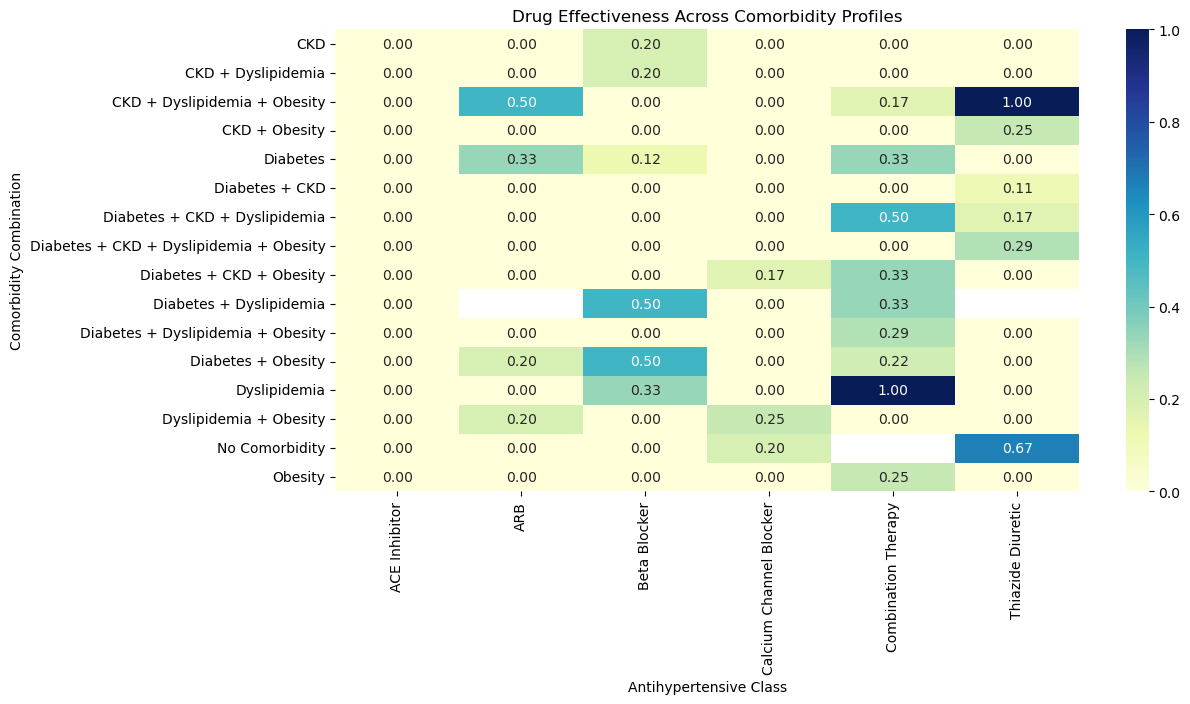

In [70]:
heatmap_data = BPd.groupby(
    ["Comorbidity_Combo", "Antihypertensive_Class"]
)["BP_Controlled_After_3_Months"].mean().unstack()

plt.figure(figsize=(12,6))
sns.heatmap(heatmap_data, annot=True, cmap="YlGnBu", fmt=".2f")

plt.title("Drug Effectiveness Across Comorbidity Profiles")
plt.xlabel("Antihypertensive Class")
plt.ylabel("Comorbidity Combination")
plt.show()


In [72]:
feature_table.to_csv("risk_factors_table.csv", index=False)
BPd.to_csv("patient_data.csv", index=False)
risk_table.to_csv("risk_table.csv", index=False)